# (i)
We consider a sum of three lognormal random variables $X_1, X_2, X_3$, and define $S = X_1 + X_2 + X_3$. We are interested in how many samples of $S$ (replications) are needed to estimate the expected value of $E[S] = \mu$ with an abseloute precision $\epsilon = 0.01.$ Number of samples needed can be estimated by the formula
$$
n = \left(\frac{z_{\alpha/2} \sigma}{\epsilon}\right)^2
$$
So for a roughly 95% we have $z_{\alpha/2} = 1.96$, and thus
$$
n = \left(\frac{1.96 \sigma}{0.01}\right)^2 = 38416 \sigma^2
$$
The varinace of a lognormal random variable is given by
$$
Var[X] = (e^{\sigma^2} - 1) e^{2\mu + \sigma^2}
$$
Since they are formed from standard normal random variables $Z_i \sim N(0,1)$, we have $\mu = 0$ and $\sigma^2 = 1$, so
$$
Var[X] = (e - 1) e
$$
And due to the independence of the $X_i$'s, we have
$$
Var[S] = Var[X_1 + X_2 + X_3] = Var[X_1] + Var[X_2] + Var[X_3] = 3(e - 1) e
$$
Thus we need $N = 38416 \cdot 14.0 \approx 540000 $

Converged at n = 44000, sigma = 3.651241626849473
Estimated n for given precision = 512126.5956724774


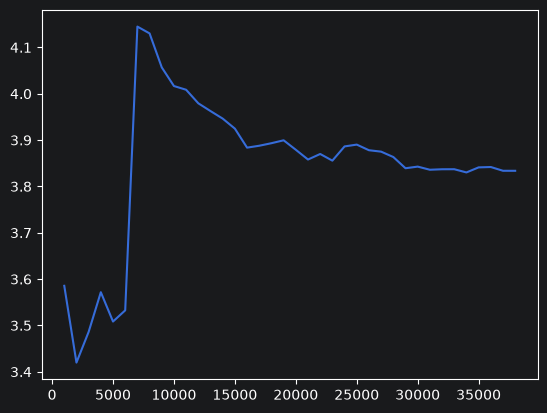

In [181]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
# First Stage
def create_s_sample(m = 3):
    z = np.random.normal(0, 1, m)
    x = np.exp(z)
    return np.sum(x)

def estimate_sigma(n, m = 3):
    samples = [create_s_sample(m) for _ in range(n)]
    return np.std(samples)

def check_convergence(sigmas, delta = 0.01):
    return np.sum(abs(np.diff(sigmas))) / np.mean(sigmas) < delta


def trial_runs(ns, m = 3, eps = 0.01, alpha = 0.05):
    # Generate a lot of samples
    samples = [create_s_sample(m) for _ in range(max(ns))]
    sigmas = []
    for n in ns:
        # Estimate the standard deviation with increasing sample size
        s = np.std(samples[:n])
        sigmas.append(s)
        if len(sigmas) > 10:
            if check_convergence(sigmas[-10:]):
                print(f"Converged at n = {n}, sigma = {s}")
                estimated_n = norm.ppf(1-alpha/2) * s / eps
                estimated_n = estimated_n**2
                print(f"Estimated n for given precision = {estimated_n}")
                return sigmas, estimated_n
            else:
                continue
    print("No convergence for the given range of n")
    return sigmas, None
ns = np.arange(1000, 100000, 1000)
s_trial, n = trial_runs(ns)
plt.plot(ns[:len(s)], s, label="n")

# (ii)
We can use the estimated number of samples to estimate the expected value of $S$ with the desired precision. We can generate $n$ samples of $S$ and compute the mean and standard deviation of these samples. The confidence interval for the mean can be computed using the formula:
$$
CI = \left(\bar{S} - z_{\alpha/2} \frac{s}{\sqrt{n}}, \bar{S} + z_{\alpha/2} \frac{s}{\sqrt{n}}\right)
$$

In [188]:
# Second Stage
s_sample = [create_s_sample() for _ in range(int(n))]
s_hat = np.mean(s_sample)
s_pilot = s_trial[-1]
s_std_full = np.std(s_sample)
CI = lambda s : (round(s_hat - norm.ppf(1-0.05/2) * s / np.sqrt(n), 4 ),
                 round(s_hat + norm.ppf(1-0.05/2) * s / np.sqrt(n), 4))
ci = CI(s_std_full)
# Rounded to 4 decimals
print(f"Estimated mean of S = {s_hat:.4f}")
print(f"True expected mean of S = {3 * np.exp(0.5):.4f}")
print(f"Estimated standard deviation of S = {s_std_full:.4f}")
print(f"Confidence interval for the mean of S = {ci}")
# Conifdence interval with pilot estimate of sigma
ci_trial = CI(s_pilot)
print(f"Confidence interval for the mean of S with pilot estimate of sigma = {ci_trial}")

Estimated mean of S = 4.9492
True expected mean of S = 4.9462
Estimated standard deviation of S = 3.7353
Confidence interval for the mean of S = (np.float64(4.939), np.float64(4.9595))
Confidence interval for the mean of S with pilot estimate of sigma = (np.float64(4.9392), np.float64(4.9592))
